### Data Pre-Processing
#### Import Packages and CSV

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler,OrdinalEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)


In [133]:
# Create Dataframe
df = pd.read_csv(r"C:\DS_Material\MLOpsSession\ML_project\VisaApprovalPrediction\notebook\Visadataset.csv")
# Print shape of dataset
print(df.shape)

(25480, 12)


### Data Cleaning
#### Handling Missing Values
- Handling Missing values
- Handling Duplicates Value
- Check data type
- Understand the dataset

1- Handling Missing values

In [134]:
na_features = df.columns.isnull().sum()
print(na_features)
print(df.info())

0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB
None


##### There is no null value in this datase

2 - Handle Duplicates

In [135]:
df.duplicated().sum()

0

- No Duplicate value in dataset

3- Remove the case_id column from dataset as its working as index column

In [136]:
df.drop(columns='case_id',inplace=True,axis=1)

In [137]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


#### Feature Engineering

##### 1- Feature Extraction

In [138]:
# importing date class from datetime module
from datetime import date
  
# creating the date object of today's date
todays_date = date.today()
current_year= todays_date.year

In [139]:
current_year

2026

In [140]:
##Creating new column from 'yr_of_estab' for better handling data
df["company_age_today"] = current_year - df['yr_of_estab']
df.drop('yr_of_estab',inplace=True,axis=1)

In [141]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age_today
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,Certified,21


##### 2- Categarize the Features

In [142]:
for features in df.columns:
    print(f"{df[features].name}: {df[features].dtype}")

continent: object
education_of_employee: object
has_job_experience: object
requires_job_training: object
no_of_employees: int64
region_of_employment: object
prevailing_wage: float64
unit_of_wage: object
full_time_position: object
case_status: object
company_age_today: int64


1- Numerical Features

In [143]:
print (f"Length of numerical features :",len([features for features in df.columns if df[features].dtype != "O"]))

Length of numerical features : 3


2- Categorical Features

In [144]:
print (f"Length of Categorical features :",len([features for features in df.columns if df[features].dtype == "O"]))


Length of Categorical features : 8


3- Discrete Features

In [145]:
numerical_features = [features for features in df.columns if df[features].dtype != "O"]
discrete_features = [features for features in numerical_features if len (df[features].unique())<=20]
print("Lenght of discrete features :",len(discrete_features))


Lenght of discrete features : 0


4- Contineous Features

In [146]:
continuous_features = [features for features in numerical_features  if features not in discrete_features]
print("Lenght of contineous features :",len(continuous_features))


Lenght of contineous features : 3


#### Splits Features in X and Y

- Split Dataframe to X and y
- Here we set a variable X i.e, independent columns, and a variable y i.e, dependent column as the “Case_Status” column.

In [147]:
X = df.drop('case_status',axis=1)

In [148]:
X.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,company_age_today
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,19
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,24
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,18
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,129
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,21


In [149]:
y= df['case_status']

In [150]:
y.head()

0       Denied
1    Certified
2       Denied
3       Denied
4    Certified
Name: case_status, dtype: object

#### Encoding for Target column


In [151]:
y = np.where(y=='Denied',1,0)
print(y)

[1 0 1 ... 0 0 0]


### Feature Transformation

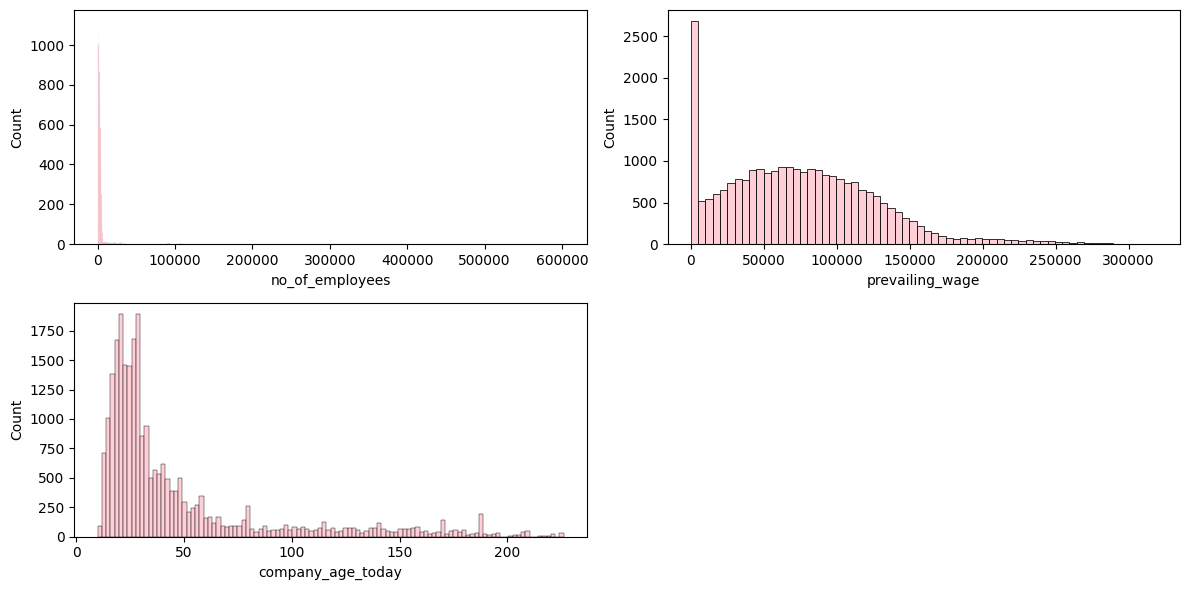

In [152]:
# distribution of data before scaling
plt.figure(figsize=(12, 6))
for i, col in enumerate(['no_of_employees','prevailing_wage','company_age_today']):
    plt.subplot(2, 2, i+1)
    sns.histplot(x=X[col], color='pink')
    plt.xlabel(col)
    plt.tight_layout()

- No of employees and Company age column is right skewed
- Apply a power transform featurewise to make data more Gaussian-like.
Power transforms are a family of parametric, monotonic transformations that are applied to make data more Gaussian-like. This is useful for modeling issues related to heteroscedasticity (non-constant variance), or other situations where normality is desired.

Currently, PowerTransformer supports the Box-Cox transform and the Yeo-Johnson transform.

**Checking Skewness**

**What is Skewness ?**

Skewness refers to a distortion or asymmetry that deviates from the symmetrical bell curve, or normal distribution, in a set of data. If the curve is shifted to the left or to the right, it is said to be skewed. Skewness can be quantified as a representation of the extent to which a given distribution varies from a normal distribution. A normal distribution has a skew of zero

In [153]:
# Check Skewness
X[continuous_features].skew(axis=0, skipna=True)

no_of_employees      12.265260
prevailing_wage       0.755776
company_age_today     2.037301
dtype: float64

- Positiviely Skewed : company_age_today, no_of_employees.
- We can handle outliers and then check the skewness.

#### Apply power transform to check if we can reduce outliers

- Here Yeo-Johnson is used and it supports both positive or negative data for transformation.
- So Power Transformer with yeo-johnson can be used.

In [154]:
pt = PowerTransformer(method='yeo-johnson')
transform_features = ['company_age_today', 'no_of_employees']
X_copy = pt.fit_transform(X[transform_features])


In [155]:
X_copy = pd.DataFrame(X_copy,columns=transform_features)

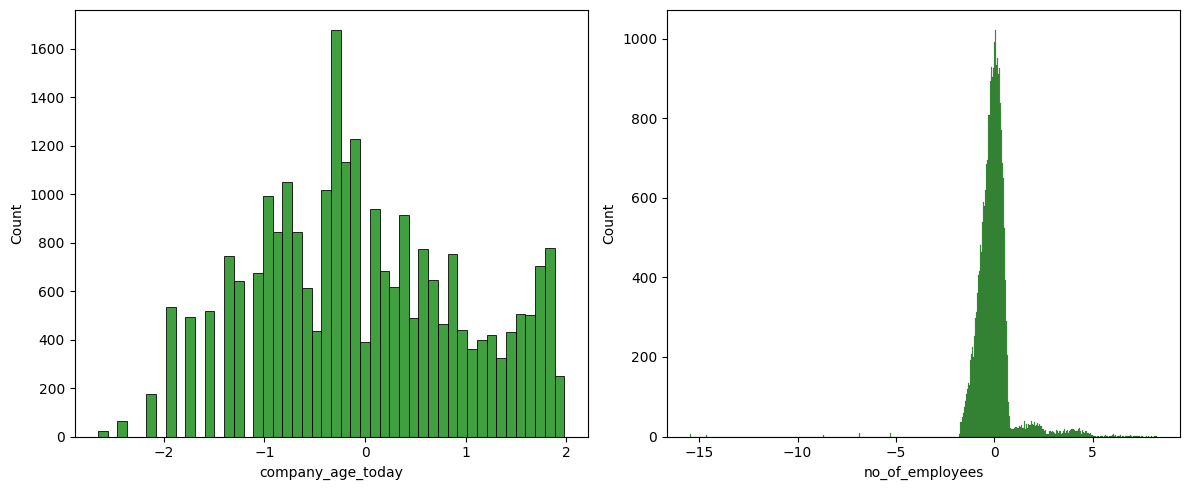

In [156]:
plt.figure(figsize=(12, 5))
for i, col in enumerate(transform_features):
    plt.subplot(1, 2, i+1)
    sns.histplot(x=X_copy[col], color='green')
    plt.xlabel(col)
    plt.tight_layout()

In [157]:
X_copy.skew(axis=0, skipna=True)

company_age_today    0.120823
no_of_employees      0.399339
dtype: float64

In [158]:
#plt.boxplot(df["prevailing_wage"])

In [159]:
categorical_features = [features for features in df.columns if df[features].dtype == "O"]
print(categorical_features)
for features in categorical_features:
    print(features,":",df[features].nunique())


['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']
continent : 6
education_of_employee : 4
has_job_experience : 2
requires_job_training : 2
region_of_employment : 5
unit_of_wage : 4
full_time_position : 2
case_status : 2


#### Feature Encoding and Scaling

**One Hot Encoding for Columns which had lesser unique values and not ordinal**

- One hot encoding is a process by which categorical variables are converted into a form that could be provided to ML algorithms to do a better job in prediction.

**Ordinal Encoding for Columns which has many unique categories**

- Ordinal encoding is used here as label encoder is supported for column transformer.
- Ordinal encoding is used for Ordinal Variable. Variable comprises a finite set of discrete values with a ranked ordering between values.

**Standard Scaler**

- Standardize features by removing the mean and scaling to unit variance.

**Power Transformer**
- Power transforms are a technique for transforming numerical input or output variables to have a Gaussian or more-Gaussian-like probability distribution.

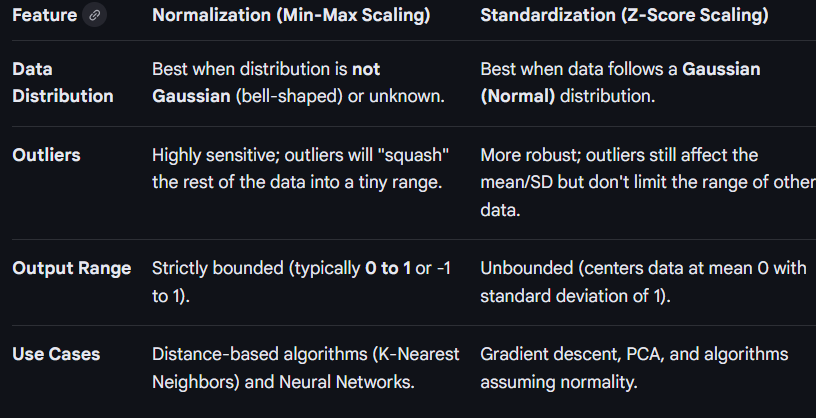

##### Selecting number features for preprocessing

In [160]:
num_features = list(X.select_dtypes(exclude="object").columns)
num_features

['no_of_employees', 'prevailing_wage', 'company_age_today']

In [161]:
# Create Column Transformer with 3 types of transformers
or_columns = ['has_job_experience','requires_job_training','full_time_position','education_of_employee']
oh_columns = ['continent','unit_of_wage','region_of_employment']
transform_columns= ['no_of_employees','company_age_today']
numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()
ordinal_encoder = OrdinalEncoder()
transform_pipe = Pipeline(steps=[
    ('transformer', PowerTransformer(method='yeo-johnson'))
])

preprocessor = ColumnTransformer([
        ("OneHotEncoder",oh_transformer,oh_columns),
        ("OrdinalEncoder",ordinal_encoder,or_columns),
        ("Transformer",transform_pipe,transform_columns),
        ("StandardScaler",numeric_transformer,num_features)
])



In [162]:

X = preprocessor.fit_transform(X)
X.shape

(25480, 24)

#### Classification

In [163]:
zeros_y = np.sum(y == 0)
ones_y = np.sum(y == 1)

print(f"Count of 0s: {zeros_y}")
print(f"Count of 1s: {ones_y}")

Count of 0s: 17018
Count of 1s: 8462


- We can see here data is hight imbalance

In [164]:
from imblearn.combine import SMOTETomek, SMOTEENN
# Resampling the minority class. The strategy can be changed as required.
smt = SMOTEENN(random_state=42,sampling_strategy='minority' )
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X, y)

- SMOTEENN(random_state=42, sampling_strategy='minority') creates a resampler that first generates synthetic samples for your smaller class and then removes noisy/overlapping data points from both classes to provide a cleaner, balanced dataset for your machine learning model.

In [165]:
print(f"Total samples in X_res: {X_res.shape[0]}")
print(f"Total samples in y_res: {y_res.shape[0]}")

Total samples in X_res: 17056
Total samples in y_res: 17056


In [166]:
zeros = np.sum(y_res == 0)
ones = np.sum(y_res == 1)

print(f"Count of 0s: {zeros}")
print(f"Count of 1s: {ones}")

Count of 0s: 7846
Count of 1s: 9210


#### Train Test Split

- The train-test split procedure is used to estimate the performance of machine learning algorithms when they are used to make predictions on data not used to train the model.

- It is a fast and easy procedure to perform, the results of which allow you to compare the performance of machine learning algorithms.

In [167]:
from sklearn.model_selection import  train_test_split
# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X_res,y_res,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((13644, 24), (3412, 24))

In [168]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [169]:
def evaluate_clf(true, predicted):
    acc = accuracy_score(true, predicted) # Calculate Accuracy
    f1 = f1_score(true, predicted) # Calculate F1-score
    precision = precision_score(true, predicted) # Calculate Precision
    recall = recall_score(true, predicted)  # Calculate Recall
    roc_auc = roc_auc_score(true, predicted) #Calculate Roc
    return acc, f1 , precision, recall, roc_auc

In [170]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(), 
     "CatBoosting Classifier": CatBoostClassifier(verbose=False),
     "Support Vector Classifier": SVC(),
    "AdaBoost Classifier": AdaBoostClassifier()

}

In [176]:
#list(models.values())[1]

In [177]:
# Create a function which can evaluate models and return a report 
def evaluate_models(X,y,models):
     '''
    This function takes in X and y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost
    '''
    # separate dataset into train and test
     X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
     models_list = []
     accuracy_list =[]
     auc=[]

     for i in range (len(list(models))):
          model = list(models.values())[i]
          model.fit(X_train,y_train)#Train the model

          #Make Predictions on training data
          y_train_pred = model.predict(X_train)      
          #Make Predictions on testing data    
          y_test_pred = model.predict(X_test)

          #Training set of performance
          model_train_accuracy, model_train_f1,model_train_precision,\
        model_train_recall,model_train_rocauc_score=evaluate_clf(y_train ,y_train_pred)
          
          # Test set performance
          model_test_accuracy,model_test_f1,model_test_precision,\
        model_test_recall,model_test_rocauc_score=evaluate_clf(y_test, y_test_pred)
          
          print(list(models.keys())[i])
          models_list.append(list(models.keys())[i])
          
          print('Model performance for Training set')
          print("- Accuracy: {:.4f}".format(model_train_accuracy))
          print('- F1 score: {:.4f}'.format(model_train_f1)) 
          print('- Precision: {:.4f}'.format(model_train_precision))
          print('- Recall: {:.4f}'.format(model_train_recall))
          print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

          print('----------------------------------')

          print('Model performance for Test set')
          print('- Accuracy: {:.4f}'.format(model_test_accuracy))
          accuracy_list.append(model_test_accuracy)
          print('- F1 score: {:.4f}'.format(model_test_f1))
          print('- Precision: {:.4f}'.format(model_test_precision))
          print('- Recall: {:.4f}'.format(model_test_recall))
          print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
          auc.append(model_test_rocauc_score)
          print('='*35)
          print('\n')

          report=pd.DataFrame(list(zip(models_list, accuracy_list)), columns=['Model Name', 'Accuracy']).sort_values(by=['Accuracy'], ascending=False)
        
     return report


     


#### Model Training

In [178]:
base_model_report =evaluate_models(X=X_res, y=y_res, models=models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9519
- F1 score: 0.9555
- Precision: 0.9566
- Recall: 0.9545
- Roc Auc Score: 0.9517


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9226
- F1 score: 0.9282
- Precision: 0.9322
- Recall: 0.9242
- Roc Auc Score: 0.9225


Gradient Boosting
Model performance for Training set
- Accuracy: 0.8860
- F1 score: 0.8944
- Precision: 0.8941
- Recall: 0.8946
- Roc Auc Score: 0.8852
----------------------------------
Model performance for Test set
- Accuracy: 0.8933
- F1 score: 0.9011
- Precision: 0.9040
- Recall: 0.8982
- Roc Auc Score: 0.8929


Logistic Regression
Model performance for Training 

##### Results of All Models

In [179]:
base_model_report

,Model Name,Accuracy
0,Random Forest,0.951934
4,K-Neighbors Classifier,0.941090
5,XGBClassifier,0.936401
6,CatBoosting Classifier,0.928195
1,Decision Tree,0.922626
2,Gradient Boosting,0.893318
7,Support Vector Classifier,0.873681
8,AdaBoost Classifier,0.860785
3,Logistic Regression,0.737104


#### Here we can use Random Forest for Hyper Parameter Tuning

#### Define the parameter distribution for Random forest

In [184]:
#Initialize few parameter for Hyperparamter tuning
xgboost_params = {
    'max_depth':range(3,10,2),
    'min_child_weight':range(1,6,2)
}

rf_params = {
    "max_depth": [10, 12, None, 15, 20],
    "max_features": ['sqrt', 'log2', None],
    "n_estimators": [10, 50, 100, 200]
}

knn_params = {
    "algorithm": ['auto', 'ball_tree', 'kd_tree','brute'],
    "weights": ['uniform', 'distance'],
    "n_neighbors": [3, 4, 5, 7, 9],
}

In [185]:
# Models list for Hyperparameter tuning
randomcv_models = [
    ('XGBoost', XGBClassifier(), xgboost_params),
    ("RF", RandomForestClassifier(), rf_params),
    ("KNN", KNeighborsClassifier(), knn_params)
]

#### Create a function for model training and report which can be used in hyperparameter tuning loop

In [186]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=3,
                                   verbose=2, 
                                   n_jobs=-1)
    random.fit(X_res, y_res)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Fitting 3 folds for each of 40 candidates, totalling 120 fits
---------------- Best Params for XGBoost -------------------
{'min_child_weight': 1, 'max_depth': 9}
---------------- Best Params for RF -------------------
{'n_estimators': 200, 'max_features': 'sqrt', 'max_depth': None}
---------------- Best Params for KNN -------------------
{'weights': 'distance', 'n_neighbors': 4, 'algorithm': 'auto'}


In [187]:
model_param

{'XGBoost': {'min_child_weight': 1, 'max_depth': 9},
 'RF': {'n_estimators': 200, 'max_features': 'sqrt', 'max_depth': None},
 'KNN': {'weights': 'distance', 'n_neighbors': 4, 'algorithm': 'auto'}}

#### Retraining the Model with best Parameters

In [188]:
from sklearn.metrics import roc_auc_score,roc_curve
best_models = {
    "Random Forest Classifier": RandomForestClassifier(**model_param['RF']),
    "KNeighborsClassifier": KNeighborsClassifier(**model_param['KNN']),
    "XGBClassifier": XGBClassifier(**model_param['XGBoost'],n_jobs=-1),
}
tuned_report =evaluate_models(X=X_res, y=y_res, models=best_models)

Random Forest Classifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9557
- F1 score: 0.9591
- Precision: 0.9593
- Recall: 0.9588
- Roc Auc Score: 0.9555


KNeighborsClassifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9719
- F1 score: 0.9743
- Precision: 0.9620
- Recall: 0.9870
- Roc Auc Score: 0.9705


XGBClassifier
Model performance for Training set
- Accuracy: 0.9994
- F1 score: 0.9995
- Precision: 0.9993
- Recall: 0.9996
- Roc Auc Score: 0.9994
----------------------------------
Model performance for Test set
- Accuracy: 0.9461
- F1 score: 0.9501
- Precision: 0.9521
- Recall: 0.9480
- Roc Auc Score: 0.9459




In [189]:

tuned_report

,Model Name,Accuracy
1,KNeighborsClassifier,0.971864
0,Random Forest Classifier,0.955744
2,XGBClassifier,0.946073


In [190]:
best_model = KNeighborsClassifier(**model_param['KNN'])
best_model = best_model.fit(X_train,y_train)
y_pred = best_model.predict(X_test)
score = accuracy_score(y_test,y_pred)
cr = classification_report(y_test,y_pred)

print("FINAL MODEL 'KNN'")
print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

FINAL MODEL 'KNN'
Accuracy Score value: 0.9719
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      1566
           1       0.96      0.99      0.97      1846

    accuracy                           0.97      3412
   macro avg       0.97      0.97      0.97      3412
weighted avg       0.97      0.97      0.97      3412



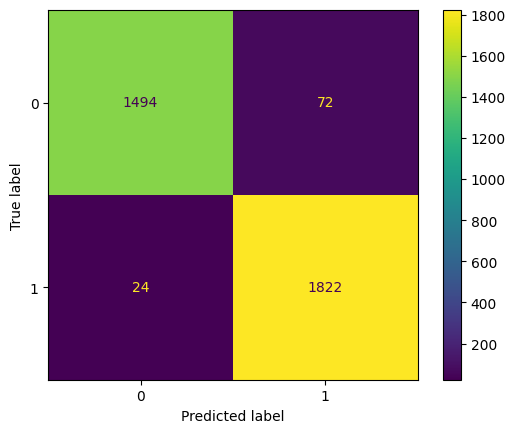

In [191]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)

#### Best Model is K-Nearest Neighbor(KNN) with Accuracy 97.18%
